# 03 - Topography (Copernicus DEM)

Operationalize DEM-based features (elevation, slope, ruggedness) and run EDA.

In [ ]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
import seaborn as sns
from IPython.display import Image, display

In [ ]:
# Locate repo root early so we can import src modules.

def _find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for parent in [start] + list(start.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError("Could not locate repo root. Run from within the repo.")


REPO_ROOT = _find_repo_root()
sys.path.append(str(REPO_ROOT / "src"))

from satellites.utils import (
    coverage_report,
    ensure_dir,
    find_repo_root,
    load_ubigeo,
    missingness_table,
    outlier_table,
    plot_corr_heatmap,
    plot_hist_ecdf,
    plot_missingness,
    raster_info,
    read_json,
    safe_read_parquet,
    select_numeric_columns,
    slope_from_window,
    tile_name,
    write_json,
)

REPO_ROOT = find_repo_root(REPO_ROOT)
np.random.seed(42)

sns.set_theme(style="whitegrid")

In [ ]:
def _show_plot(path: Path, title: str) -> None:
    if not path.exists():
        print(f"[plot missing] {title}: {path}")
        return
    print(f"[plot] {title}: {path}")
    display(Image(filename=str(path)))

## Setup

In [ ]:
RAW_DIR = REPO_ROOT / "data" / "external" / "raw" / "topography"
TILES_DIR = RAW_DIR / "copernicus_cog30_tiles"
RAW_META_PATH = RAW_DIR / "metadata.json"

PROCESSED_DIR = REPO_ROOT / "data" / "external" / "processed"
UBIGEO_PATH = PROCESSED_DIR / "ubigeo_district_capitals.parquet"
UBIGEO_FALLBACK = REPO_ROOT / "data" / "external" / "raw" / "ubigeo" / "ubigeo_distrito.csv"
UBIGEO_PLAN_A = REPO_ROOT / "data" / "external" / "raw" / "ubigeo" / "DD_TB_UBIGEOS.xlsx"

REPORT_DIR = ensure_dir(REPO_ROOT / "reports" / "satellites" / "03_topography")

RAW_META = read_json(RAW_META_PATH)
OUT_PARQUET = PROCESSED_DIR / "topography_district_features.parquet"
OUT_META = REPORT_DIR / "topography_metadata.json"
QA_SUMMARY_PATH = REPORT_DIR / "qa_summary.json"

## Load UBIGEO and raw metadata

In [ ]:
ubigeo = load_ubigeo(UBIGEO_PATH, UBIGEO_FALLBACK, fallback_excel=UBIGEO_PLAN_A, write_back=True)

print(f"UBIGEO rows: {len(ubigeo)}")
print("Missing capital coordinates:", ubigeo[["capital_lat", "capital_lon"]].isna().any(axis=1).sum())

UBIGEO rows: 1892
Missing capital coordinates: 18


## Load + Raw QA

In [ ]:
if not TILES_DIR.exists():
    raise FileNotFoundError(f"Missing tiles directory: {TILES_DIR}")

# Sample a tile for metadata
sample_tile = next(TILES_DIR.glob("Copernicus_DSM_COG_30_*.tif"), None)
if sample_tile is None:
    raise FileNotFoundError("No Copernicus DEM tiles found.")

sample_info = raster_info(sample_tile)
print("Sample DEM info:", sample_info)

if sample_info["bounds"] is None or sample_info["res"] is None:
    raise ValueError("DEM raster bounds/resolution metadata missing.")

if sample_info["nodata"] is None:
    print("Warning: DEM nodata is None; missing values may be under-detected.")

Sample DEM info: {'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]'), 'bounds': BoundingBox(left=-77.00041666666667, bottom=-8.999583333333334, right=-76.00041666666667, top=-7.999583333333334), 'res': (0.0008333333333333334, 0.0008333333333333334), 'nodata': None, 'dtype': 'float32', 'count': 1, 'shape': (1200, 1200)}


## Operationalization / Pre-processing

In [ ]:
valid_mask = ubigeo[["capital_lat", "capital_lon"]].notna().all(axis=1).to_numpy()
valid = ubigeo.loc[valid_mask].copy()
valid["tile"] = [
    tile_name(lat, lon) for lat, lon in zip(valid["capital_lat"], valid["capital_lon"])
]
valid["idx"] = np.flatnonzero(valid_mask)

n = len(ubigeo)
elev = np.full(n, np.nan)
slope = np.full(n, np.nan)
rugged = np.full(n, np.nan)

missing_tiles = []

for tile, group in valid.groupby("tile"):
    tile_path = TILES_DIR / f"{tile}.tif"
    if not tile_path.exists():
        missing_tiles.append(tile)
        continue

    with rasterio.open(tile_path) as ds:
        xres, yres = ds.res
        for _, row in group.iterrows():
            lon = float(row["capital_lon"])
            lat = float(row["capital_lat"])
            idx = int(row["idx"])
            try:
                r, c = ds.index(lon, lat)
            except Exception:
                continue

            fill_value = ds.nodata if ds.nodata is not None else np.nan
            window = ds.read(1, window=Window(c - 1, r - 1, 3, 3), boundless=True, fill_value=fill_value)
            if ds.nodata is not None:
                window = np.where(window == ds.nodata, np.nan, window)
            center = window[1, 1]
            dx = abs(xres) * 111320 * np.cos(np.deg2rad(lat))
            dy = abs(yres) * 111320

            elev[idx] = center
            slope[idx] = slope_from_window(window, dx, dy)
            rugged[idx] = float(np.nanstd(window))

out = pd.DataFrame(
    {
        "ubigeo6": ubigeo["ubigeo6"].astype("string"),
        "elev_m": elev,
        "slope_deg": slope,
        "ruggedness": rugged,
    }
)

if not out["ubigeo6"].is_unique:
    raise ValueError("Output ubigeo6 keys are not unique.")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out.to_parquet(OUT_PARQUET, index=False)
print(f"Wrote {OUT_PARQUET}")

meta = {
    "source": RAW_META.get("source", "Copernicus DEM GLO-90"),
    "tiles": RAW_META.get("tile_count"),
    "missing_tiles": sorted(set(missing_tiles)),
    "units": {
        "elev_m": "meters",
        "slope_deg": "degrees",
        "ruggedness": "meters (std dev of 3x3 window)",
    },
    "nodata": sample_info["nodata"],
    "crs": str(sample_info["crs"]),
    "resolution": sample_info["res"],
}

write_json(OUT_META, meta)

Wrote /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/topography_district_features.parquet


ERROR 1: PROJ: internal_proj_identify: /Users/gabrielsaco/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


## QA summary

In [ ]:
missing_table = missingness_table(out)
summary_stats = out[select_numeric_columns(out, exclude=["ubigeo6"])].describe().T[
    ["min", "max", "mean", "std"]
]
coverage_table, missing_keys = coverage_report(out, ubigeo)

qa_summary = {
    "row_count": int(len(out)),
    "ubigeo_unique": bool(out["ubigeo6"].is_unique),
    "missing_keys": missing_keys[:50],
    "missing_key_count": int(len(missing_keys)),
    "missingness": missing_table.to_dict(orient="records"),
    "summary_stats": summary_stats.reset_index().rename(columns={"index": "feature"}).to_dict(orient="records"),
    "coverage": coverage_table.to_dict(orient="records"),
}

write_json(QA_SUMMARY_PATH, qa_summary)
print(f"Wrote {QA_SUMMARY_PATH}")

Wrote /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/03_topography/qa_summary.json


## EDA outputs

[plot] Missingness by column: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/03_topography/missingness_plot.png


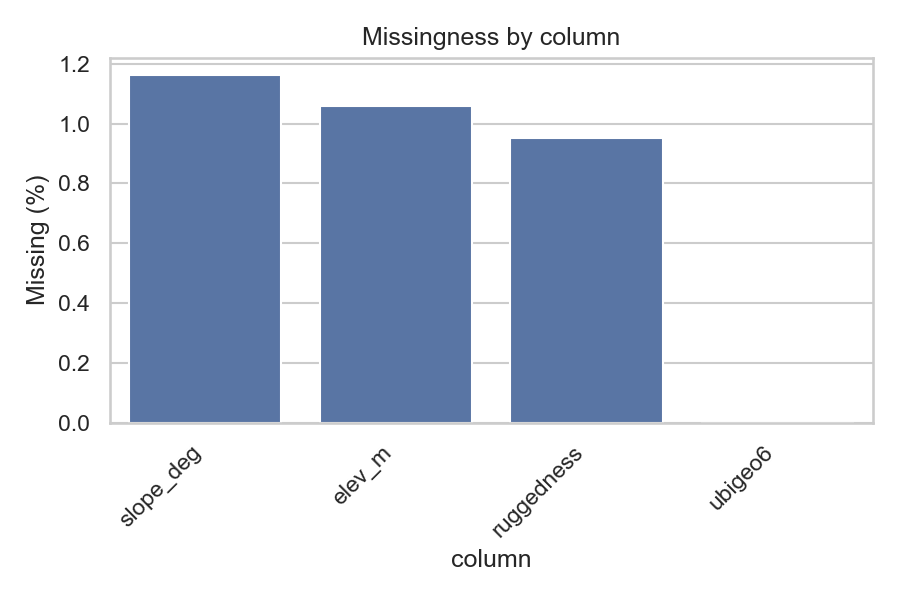

[plot] Feature distributions: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/03_topography/feature_distributions.png


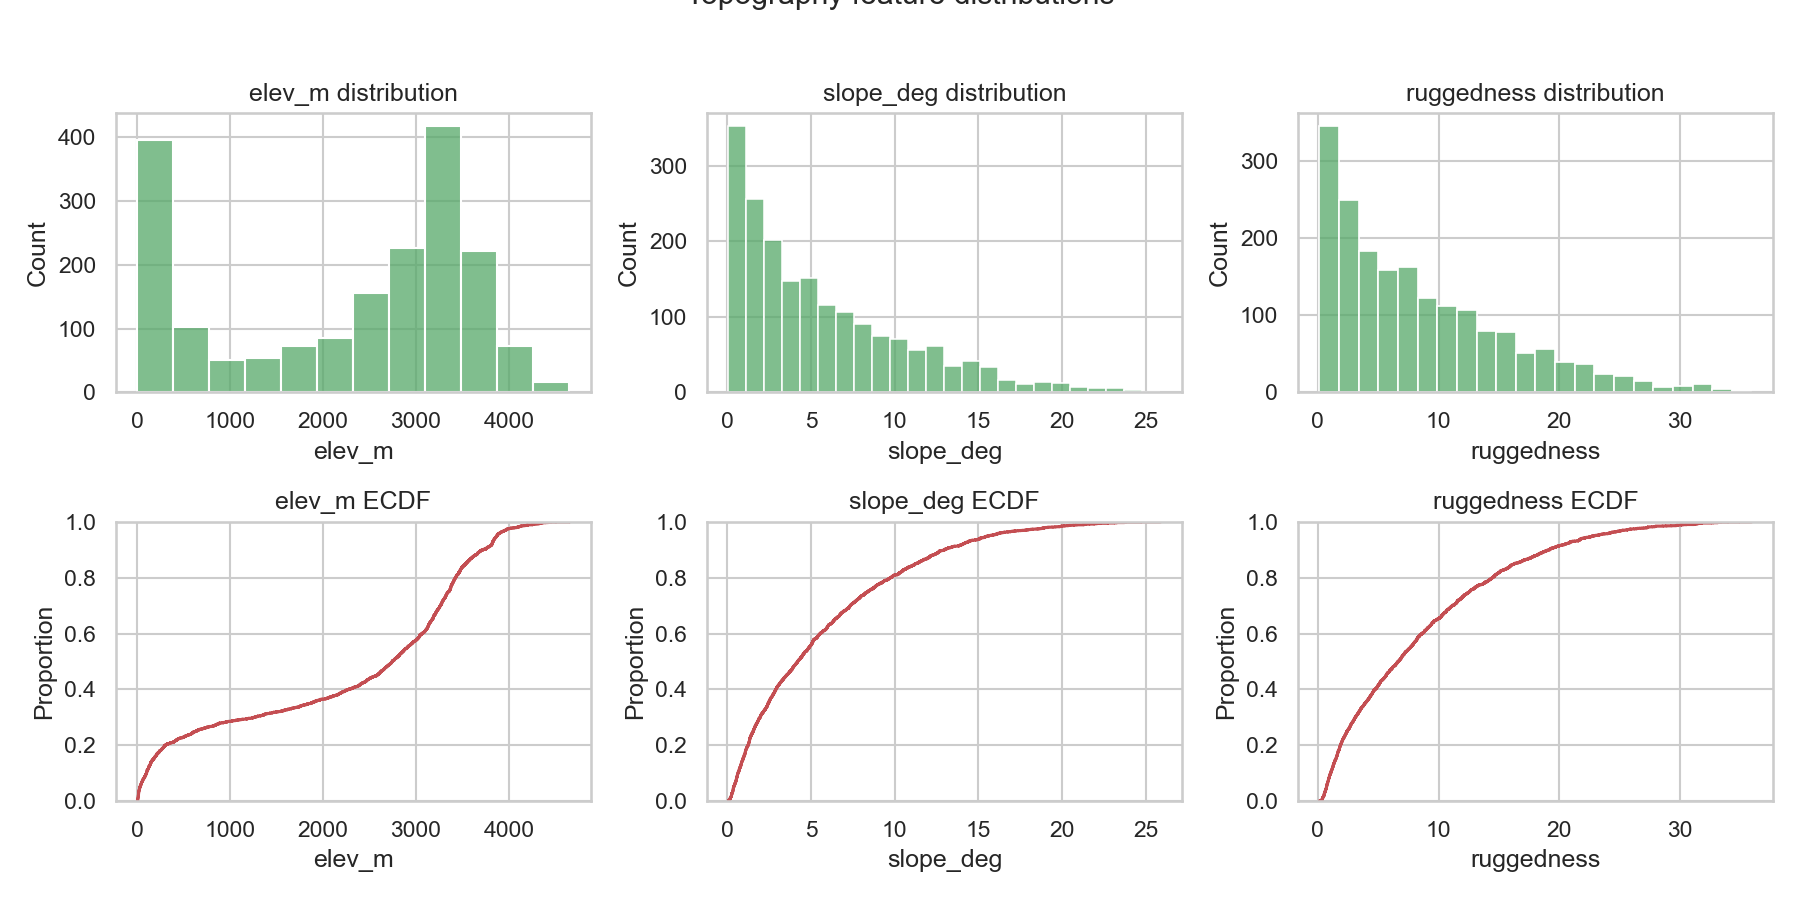

[plot] Topography correlations: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/03_topography/corr_topography_only.png


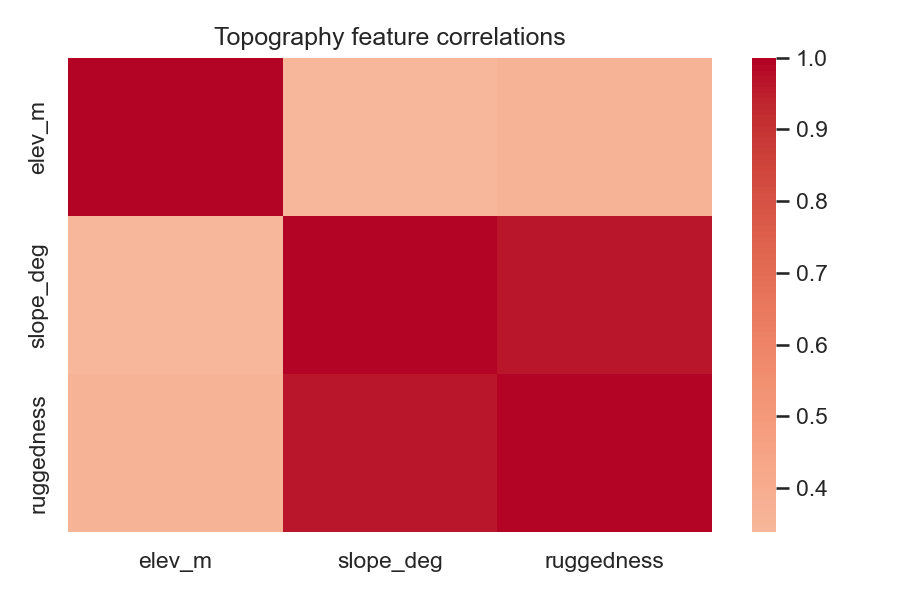

[plot] Topography + other satellites: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/03_topography/corr_with_other_satellites.png


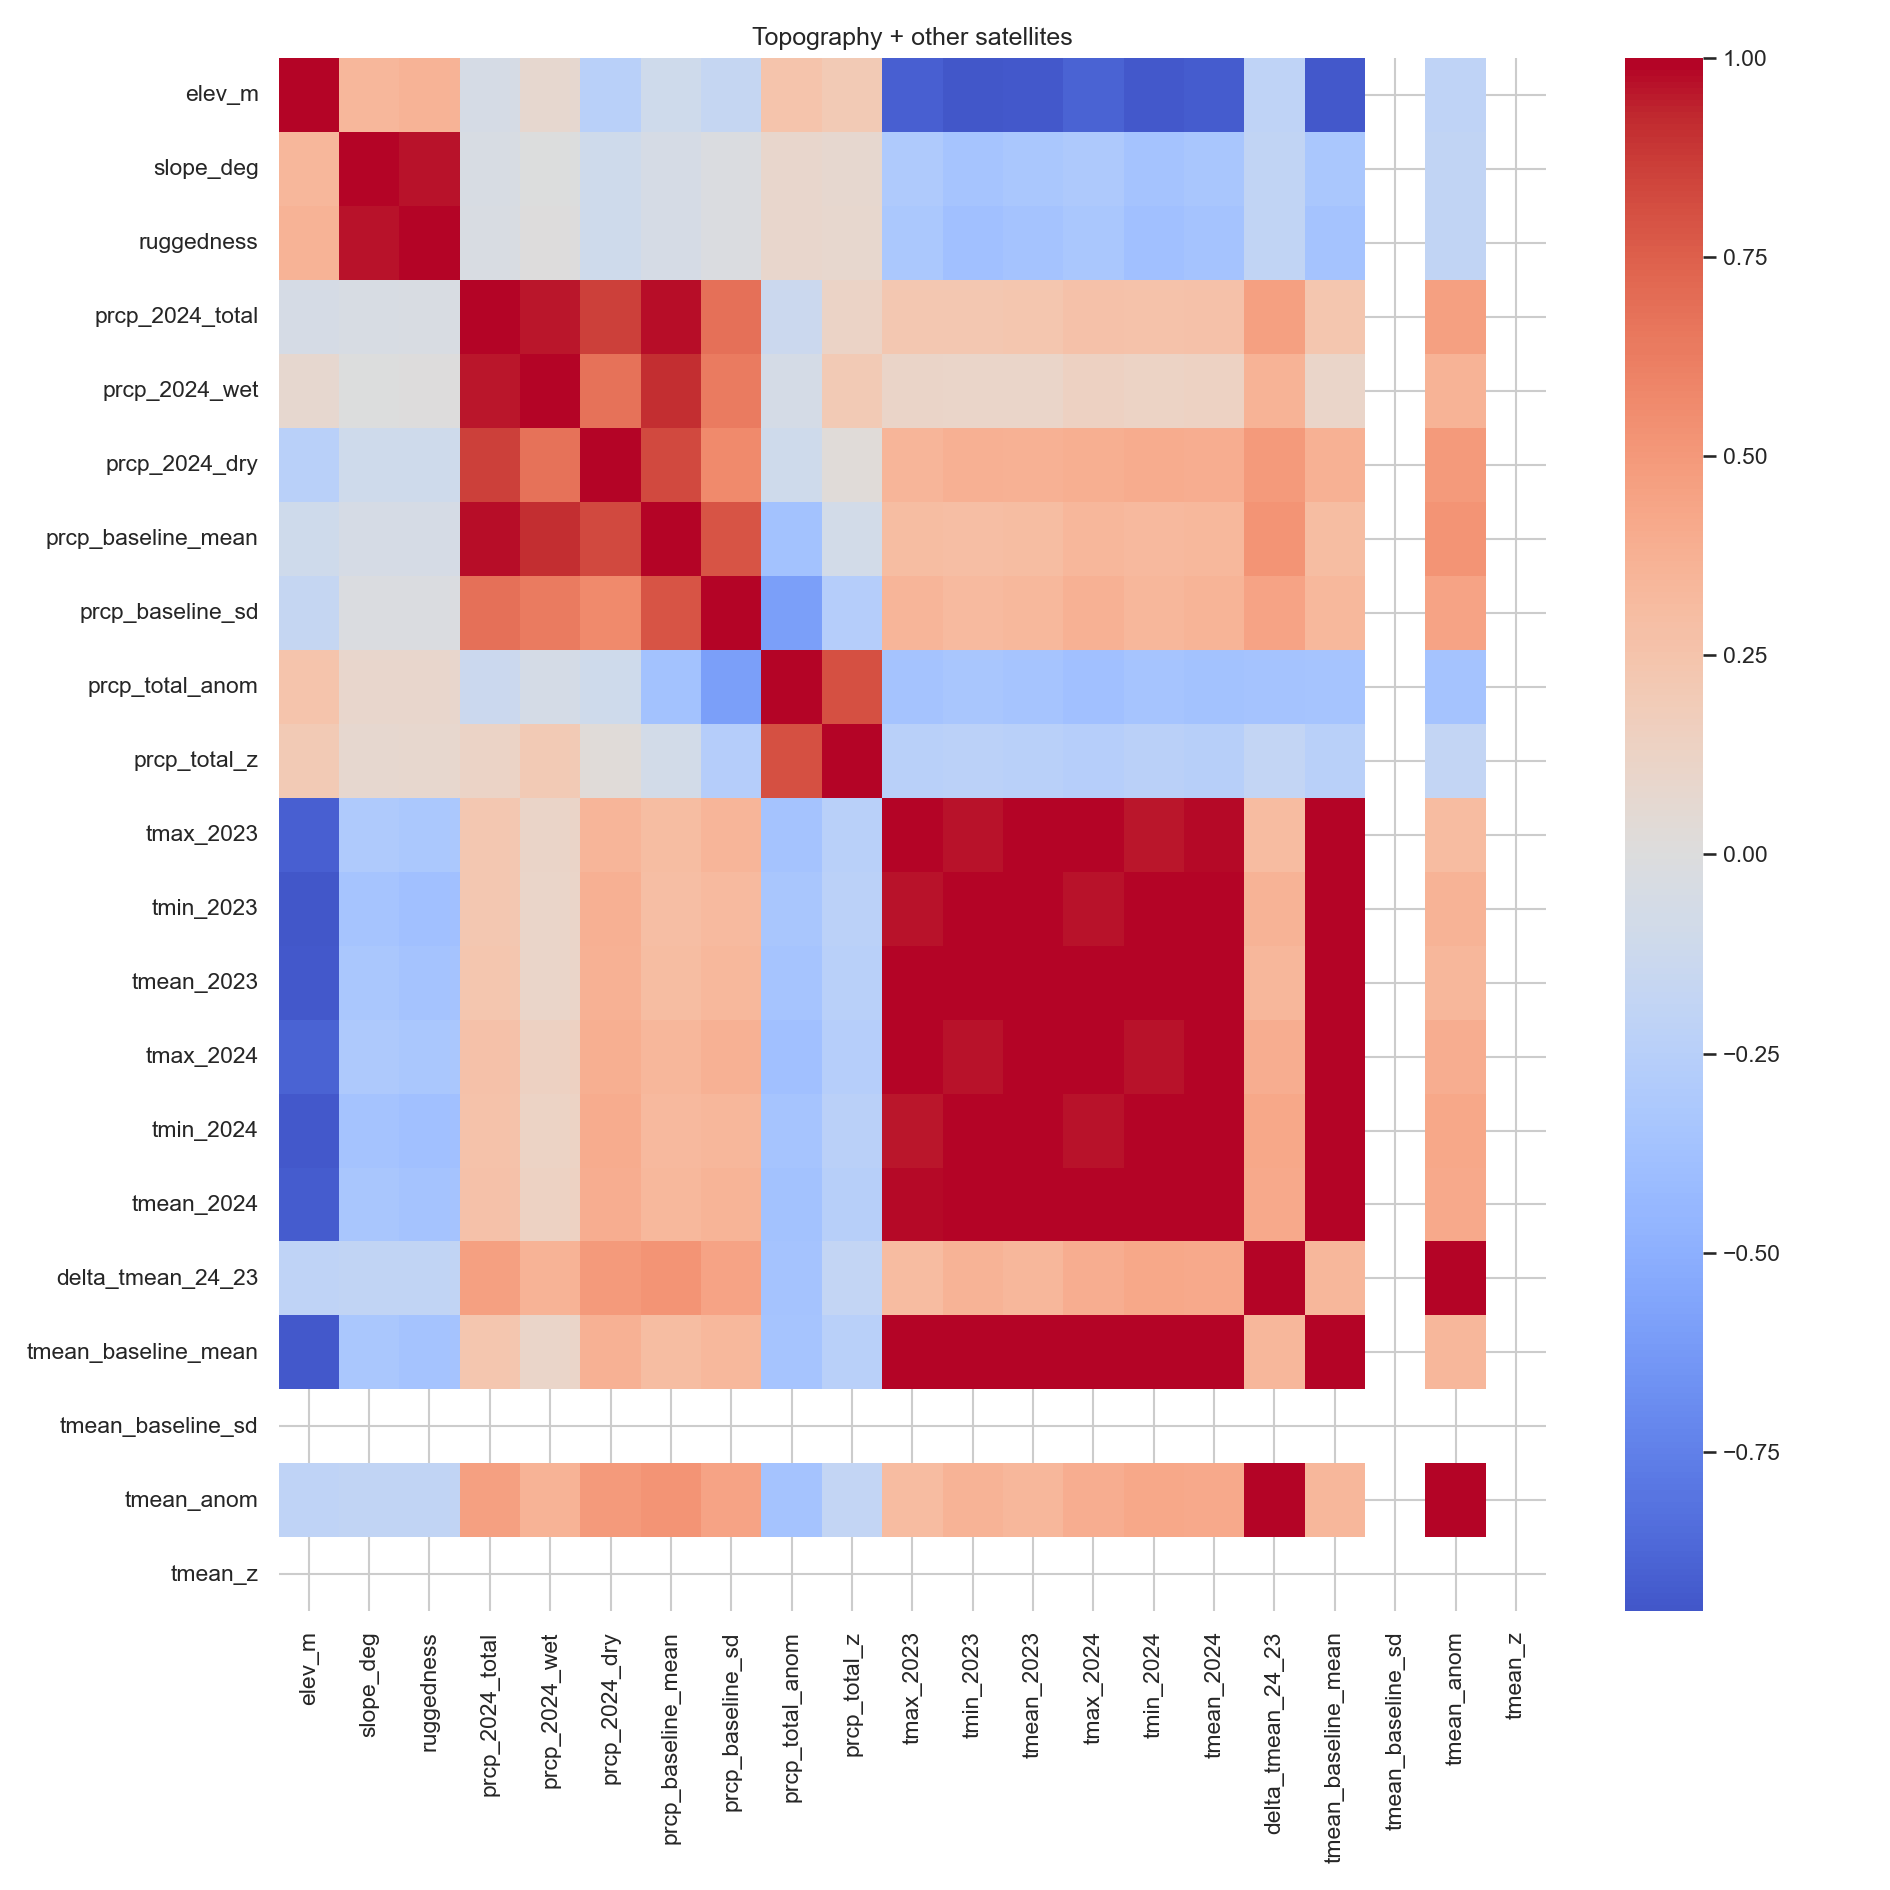

In [ ]:
missing_table_path = REPORT_DIR / "missingness_table.csv"
missing_table.to_csv(missing_table_path, index=False)
plot_missingness(missing_table, REPORT_DIR / "missingness_plot.png", "Missingness by column")
_show_plot(REPORT_DIR / "missingness_plot.png", "Missingness by column")

key_features = ["elev_m", "slope_deg", "ruggedness"]
plot_hist_ecdf(out, key_features, REPORT_DIR / "feature_distributions.png", "Topography feature distributions")
_show_plot(REPORT_DIR / "feature_distributions.png", "Feature distributions")

outliers = outlier_table(out, key_features)
outliers.to_csv(REPORT_DIR / "outliers_top_bottom_20.csv", index=False)

coverage_table.to_csv(REPORT_DIR / "coverage_report.csv", index=False)

# Correlations within topography features
corr = out[select_numeric_columns(out, exclude=["ubigeo6"])].corr()
plot_corr_heatmap(corr, REPORT_DIR / "corr_topography_only.png", "Topography feature correlations")
_show_plot(REPORT_DIR / "corr_topography_only.png", "Topography correlations")

# Correlation with other satellite features if available
other_paths = {
    "precip": PROCESSED_DIR / "chirps_district_features_2024.parquet",
    "temperature": PROCESSED_DIR / "temperature_district_features_2023_2024.parquet",
}

other_frames = []
for name, path in other_paths.items():
    df = safe_read_parquet(path, required=False)
    if df is not None:
        other_frames.append(df)

if other_frames:
    merged = out.copy()
    for df in other_frames:
        merged = merged.merge(df, on="ubigeo6", how="left")
    corr_all = merged[select_numeric_columns(merged, exclude=["ubigeo6"])].corr()
    plot_corr_heatmap(corr_all, REPORT_DIR / "corr_with_other_satellites.png", "Topography + other satellites")
    _show_plot(REPORT_DIR / "corr_with_other_satellites.png", "Topography + other satellites")

## End-of-notebook checklist

In [ ]:
print("Output parquet:", OUT_PARQUET)
print("Report folder:", REPORT_DIR)
print("Summary:")
print("- Computed elevation, slope, ruggedness at district capital points")
print("- Units: meters for elevation/ruggedness, degrees for slope")
print("- Caveats: missing tiles or nodata values yield NaN")

Output parquet: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/topography_district_features.parquet
Report folder: /Users/gabrielsaco/Documents/GitHub/sfa_ciup/reports/satellites/03_topography
Summary:
- Computed elevation, slope, ruggedness at district capital points
- Units: meters for elevation/ruggedness, degrees for slope
- Caveats: missing tiles or nodata values yield NaN
